In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
!pip install optuna

import os
import gc
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
import tensorflow as tf

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Input, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Configuração Global
DATASET_PATH = "/content/drive/MyDrive/2026/ic/npz_files/sbhar_v2.npz"
SEED = 42

def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seeds(SEED)

In [41]:
# ==========================================
# 1. CARREGAMENTO E DIVISÃO
# ==========================================
def load_and_split_data(path):
    print(f" Carregando dataset: {path}...")
    try:
        data = np.load(path, allow_pickle=True)
        X_train = data['X_train']
        y_train = data['y_train']
        X_val = data['X_val']
        y_val = data['y_val']
        X_test = data['X_test']
        y_test = data['y_test']
        classes = data['classes']
    except FileNotFoundError:
        print(" Erro: Arquivo .npz não encontrado.")
        return None

    num_classes = len(classes)

    print(f"   Dados Carregados. Classes: {num_classes}")
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), num_classes


In [42]:
# ==========================================
# 2. PREPARAÇÃO DE DADOS (RAW vs FEATURES)
# ==========================================
def prep_dl_data(X_train, X_val, X_test, mode='raw'):
    """
    mode='raw': CNN-1D. Os dados já vêm normalizados do NPZ. Apenas repassa.
    mode='features': MLP. Extrai features estatísticas e normaliza.
    """
    scaler = StandardScaler()

    if mode == 'raw':
        # Os dados do arquivo .npz já foram devidamente padronizados no
        # pipeline anterior com .fit no treino e .transform na validação e teste.
        return X_train, X_val, X_test

    elif mode == 'features':
        # MLP espera (N, Features)
        def extract(X):
            if X is None: return None
            # Média, Desvio, Max, Min
            return np.hstack([
                np.mean(X, axis=1), np.std(X, axis=1),
                np.max(X, axis=1), np.min(X, axis=1)
            ])

        X_tr_feat = extract(X_train)
        X_val_feat = extract(X_val)
        X_te_feat = extract(X_test)

        # Fit no treino e Transform
        X_tr_sc = scaler.fit_transform(X_tr_feat)
        X_val_sc = scaler.transform(X_val_feat) if X_val_feat is not None else None
        X_te_sc = scaler.transform(X_te_feat)

        return X_tr_sc, X_val_sc, X_te_sc


In [43]:
# ==========================================
# 3. ARQUITETURAS (CNN & MLP)
# ==========================================
def build_cnn(input_shape, n_classes, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # Bloco Conv 1
    model.add(Conv1D(filters=params.get('filters_1', 64),
                     kernel_size=params.get('kernel_1', 7), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(2))
    model.add(Dropout(params.get('dropout', 0.2)))

    # Bloco Conv 2
    model.add(Conv1D(filters=params.get('filters_2', 128),
                     kernel_size=params.get('kernel_2', 5), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling1D()) # Reduz tudo para vetor
    model.add(Dropout(params.get('dropout', 0.3)))

    # Dense Head
    model.add(Dense(params.get('dense_units', 64), activation='relu'))
    model.add(Dense(n_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def build_mlp(input_shape, n_classes, params):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # Dense 1
    model.add(Dense(params.get('units_1', 128), activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(params.get('dropout', 0.3)))

    # Dense 2
    model.add(Dense(params.get('units_2', 64), activation='relu'))
    model.add(BatchNormalization())

    model.add(Dense(n_classes, activation='softmax'))

    model.compile(optimizer=Adam(learning_rate=params.get('lr', 1e-3)),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [44]:
# ==========================================
# 4. OPTUNA
# ==========================================
def run_optuna_dl(X_train, y_train, X_val, y_val, mode, num_classes, n_trials=10):

    def objective(trial):
        params = {
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'dropout': trial.suggest_float('dropout', 0.1, 0.5),
            'weight_factor': trial.suggest_float('weight_factor', 0.0, 1.0)
        }

        if mode == 'raw':
            params.update({
                'filters_1': trial.suggest_categorical('filters_1', [32, 64]),
                'kernel_1': trial.suggest_int('kernel_1', 3, 9, step=2),
                'filters_2': trial.suggest_categorical('filters_2', [64, 128]),
                'kernel_2': trial.suggest_int('kernel_2', 3, 7, step=2),
                'dense_units': trial.suggest_int('dense_units', 32, 128)
            })
            model = build_cnn(X_train.shape[1:], num_classes, params)
        else:
            params.update({
                'units_1': trial.suggest_int('units_1', 64, 256),
                'units_2': trial.suggest_int('units_2', 32, 128)
            })
            model = build_mlp(X_train.shape[1:], num_classes, params)

        from sklearn.utils.class_weight import compute_class_weight
        unique_classes = np.unique(y_train)
        balanced_weights = compute_class_weight('balanced', classes=unique_classes, y=y_train)
        cw_dict = {cls: 1.0 + (w - 1.0) * params['weight_factor'] for cls, w in zip(unique_classes, balanced_weights)}

        # Treino rápido para Optuna
        es = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
        history = model.fit(
            X_train, y_train, validation_data=(X_val, y_val),
            epochs=15, batch_size=64, verbose=0, callbacks=[es],
            class_weight=cw_dict
        )

        # Prever no conjunto de validação para calcular F1-Macro
        y_pred_val_prob = model.predict(X_val, verbose=0)
        y_pred_val_labels = np.argmax(y_pred_val_prob, axis=1)
        f1_macro_val = f1_score(y_val, y_pred_val_labels, average='macro')

        return f1_macro_val

    print(f"    Otimizando {mode.upper()} ({n_trials} trials)...")
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)
    print(f"      Melhores Params: {study.best_params}")
    return study.best_params

In [45]:
# ==========================================
# 5. EXECUÇÃO DE EXPERIMENTOS
# ==========================================
def run_experiment(X_train, y_train, X_val, y_val, X_test, y_test, params, mode, num_classes):

    # Construir Modelo
    if mode == 'raw':
        model = build_cnn(X_train.shape[1:], num_classes, params)
    else:
        model = build_mlp(X_train.shape[1:], num_classes, params)

    # Callbacks
    es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Treino Final usando a validação subject-independent
    print("   Treinando modelo final...")
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val), # Sem vazamento de dados de usuários
        epochs=50, batch_size=32, verbose=0,
        callbacks=[es]
    )

    # Prever no conjunto de teste
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # Avaliação Bootstrap
    print("   Calculando métricas via Bootstrap...")
    f1_scores = []
    acc_scores = []
    n_size = len(y_test)
    for _ in range(30): # 30 iterações
        indices = np.random.randint(0, n_size, n_size)

        # Reamostramos os rótulos reais e as predições
        y_sample = y_test[indices]
        sample_preds = y_pred[indices]

        f1_scores.append(f1_score(y_sample, sample_preds, average='macro'))
        acc_scores.append(accuracy_score(y_sample, sample_preds))

    f1_mean = np.mean(f1_scores)
    f1_lower = np.percentile(f1_scores, 2.5)
    f1_upper = np.percentile(f1_scores, 97.5)

    acc_mean = np.mean(acc_scores)
    acc_lower = np.percentile(acc_scores, 2.5)
    acc_upper = np.percentile(acc_scores, 97.5)

    print(f"   [Bootstrap] F1: {f1_mean:.4f} | Acc: {acc_mean:.4f}")

    return {
        "F1_Mean": f1_mean, "F1_Lower": f1_lower, "F1_Upper": f1_upper,
        "Acc_Mean": acc_mean, "Acc_Lower": acc_lower, "Acc_Upper": acc_upper,
        "y_test_true": y_test, "y_pred_model": y_pred
    }

 Carregando dataset: /content/drive/MyDrive/2026/ic/npz_files/sbhar_v2.npz...
   Dados Carregados. Classes: 12

>>> CENÁRIO: Raw Data (CNN) <<<
   Usando Parâmetros Default
   Treinando modelo final...
   Calculando métricas via Bootstrap...
   [Bootstrap] F1: 0.8454 | Acc: 0.9131

>>> CENÁRIO: Feature Eng (MLP) <<<
   Usando Parâmetros Default
   Treinando modelo final...
   Calculando métricas via Bootstrap...
   [Bootstrap] F1: 0.7493 | Acc: 0.8556


[I 2026-04-20 02:17:09,151] A new study created in memory with name: no-name-450af96b-9a4b-4305-ae09-72de037a6b39



>>> CENÁRIO: Raw + Optuna <<<
    Otimizando RAW (10 trials)...


[I 2026-04-20 02:17:58,966] Trial 0 finished with value: 0.730920762581055 and parameters: {'lr': 0.0017194858942842057, 'dropout': 0.1809853514334098, 'weight_factor': 0.5442561460944958, 'filters_1': 64, 'kernel_1': 7, 'filters_2': 128, 'kernel_2': 3, 'dense_units': 118}. Best is trial 0 with value: 0.730920762581055.
[I 2026-04-20 02:18:58,083] Trial 1 finished with value: 0.8828532358362909 and parameters: {'lr': 0.0003482704230853445, 'dropout': 0.45621322970706524, 'weight_factor': 0.30862226895777556, 'filters_1': 32, 'kernel_1': 9, 'filters_2': 64, 'kernel_2': 3, 'dense_units': 112}. Best is trial 1 with value: 0.8828532358362909.
[I 2026-04-20 02:19:55,697] Trial 2 finished with value: 0.8117718184802137 and parameters: {'lr': 0.00048695953367889575, 'dropout': 0.4725944054596425, 'weight_factor': 0.34958919963335455, 'filters_1': 32, 'kernel_1': 3, 'filters_2': 64, 'kernel_2': 3, 'dense_units': 32}. Best is trial 1 with value: 0.8828532358362909.
[I 2026-04-20 02:20:52,418] T

      Melhores Params: {'lr': 0.0002677851122727506, 'dropout': 0.12434195042439233, 'weight_factor': 0.9607957990363386, 'filters_1': 64, 'kernel_1': 9, 'filters_2': 64, 'kernel_2': 5, 'dense_units': 97}
   Treinando modelo final...
   Calculando métricas via Bootstrap...
   [Bootstrap] F1: 0.8481 | Acc: 0.9248

>>> CENÁRIO: Feat + Optuna <<<


[I 2026-04-20 02:34:04,708] A new study created in memory with name: no-name-454dd734-fc35-4ff0-8d7c-df6a39e670ab


    Otimizando FEATURES (10 trials)...


[I 2026-04-20 02:34:14,306] Trial 0 finished with value: 0.8520427840235283 and parameters: {'lr': 0.001647153791842619, 'dropout': 0.10049062002174143, 'weight_factor': 0.5782477084546281, 'units_1': 224, 'units_2': 71}. Best is trial 0 with value: 0.8520427840235283.
[I 2026-04-20 02:34:27,729] Trial 1 finished with value: 0.7919681228067397 and parameters: {'lr': 0.0006361077315662881, 'dropout': 0.21937240835732297, 'weight_factor': 0.7891170550213674, 'units_1': 172, 'units_2': 99}. Best is trial 0 with value: 0.8520427840235283.
[I 2026-04-20 02:34:40,665] Trial 2 finished with value: 0.8492302758796151 and parameters: {'lr': 0.0006057186872416425, 'dropout': 0.2374660229669824, 'weight_factor': 0.6301338317280277, 'units_1': 107, 'units_2': 107}. Best is trial 0 with value: 0.8520427840235283.
[I 2026-04-20 02:34:53,769] Trial 3 finished with value: 0.8633703808269027 and parameters: {'lr': 0.002744809617373221, 'dropout': 0.11148343820007703, 'weight_factor': 0.7454175200467771

      Melhores Params: {'lr': 0.002744809617373221, 'dropout': 0.11148343820007703, 'weight_factor': 0.7454175200467771, 'units_1': 223, 'units_2': 88}
   Treinando modelo final...
   Calculando métricas via Bootstrap...
   [Bootstrap] F1: 0.7786 | Acc: 0.8337


=== RELATÓRIO FINAL (SBHAR - Deep Learning) ===
 F1_Mean  F1_Lower  F1_Upper  Acc_Mean  Acc_Lower  Acc_Upper          Scenario
0.845421  0.814999  0.870815  0.913079   0.903840   0.917115    Raw Data (CNN)
0.749276  0.724010  0.770655  0.855583   0.848145   0.865679 Feature Eng (MLP)
0.848081  0.821346  0.872170  0.924804   0.917305   0.933244      Raw + Optuna
0.778626  0.744144  0.809206  0.833669   0.816634   0.844450     Feat + Optuna


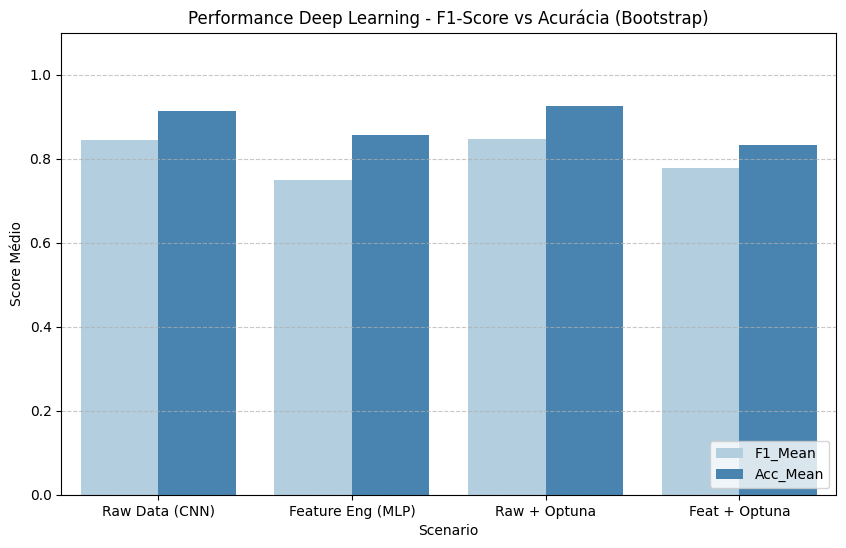

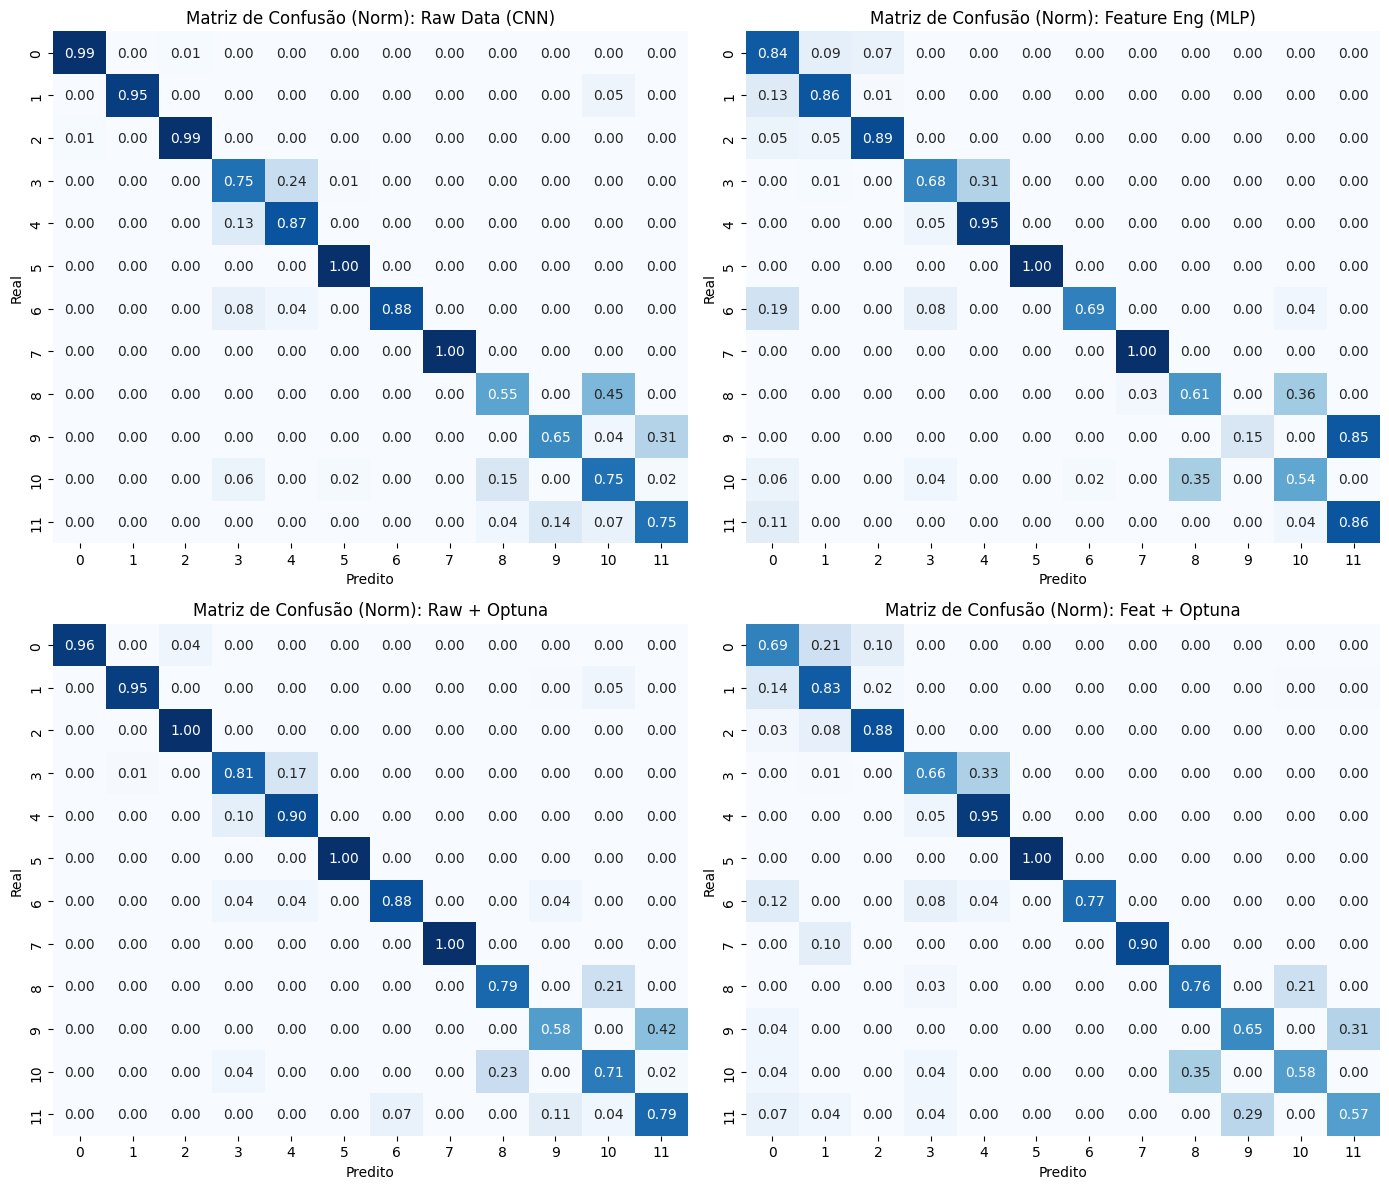

In [46]:
# ==========================================
# 6. LOOP PRINCIPAL
# ==========================================
from sklearn.metrics import confusion_matrix

data_splits = load_and_split_data(DATASET_PATH)

if data_splits:
    (X_tr, y_tr), (X_val, y_val), (X_te, y_te), NUM_CLASSES = data_splits

    results = []

    # Cenários: (Nome do Cenário, Modo de Dados, Usar Optuna)
    scenarios = [
        ("Raw Data (CNN)", "raw", False),
        ("Feature Eng (MLP)", "features", False),
        ("Raw + Optuna", "raw", True),
        ("Feat + Optuna", "features", True)
    ]

    for label, mode, use_optuna in scenarios:
        print(f"\n>>> CENÁRIO: {label} <<<")

        # 1. Preparar Dados Finais (Extração de features se MLP)
        X_tr_sc, X_val_sc, X_te_sc = prep_dl_data(X_tr, X_val, X_te, mode)

        # 2. Definir Parâmetros
        if use_optuna:
            best_params = run_optuna_dl(X_tr_sc, y_tr, X_val_sc, y_val, mode, NUM_CLASSES, n_trials=10)
        else:
            print("   Usando Parâmetros Default")
            best_params = {}

        # 3. Rodar Experimento
        res = run_experiment(X_tr_sc, y_tr, X_val_sc, y_val, X_te_sc, y_te, best_params, mode, NUM_CLASSES)
        res['Scenario'] = label
        results.append(res)

        # Limpar Memória GPU/RAM
        tf.keras.backend.clear_session()
        gc.collect()

    # ==========================================
    # RELATÓRIO E GRÁFICOS
    # ==========================================
    df_res = pd.DataFrame(results)

    # Tabela de Resultados (removendo as predições para exibição)
    df_table = df_res.drop(columns=['y_test_true', 'y_pred_model'])
    print("\n\n=== RELATÓRIO FINAL (SBHAR - Deep Learning) ===")
    print(df_table.to_string(index=False))

    # Preparar dados para o Histograma/Barplot comparativo
    df_melt = df_table.melt(
        id_vars=['Scenario'],
        value_vars=['F1_Mean', 'Acc_Mean'],
        var_name='Métrica',
        value_name='Score'
    )

    # Gráfico 1: Histograma Azul (Comparação de F1 e Acc)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_melt, x='Scenario', y='Score', hue='Métrica', palette='Blues')
    plt.title("Performance Deep Learning - F1-Score vs Acurácia (Bootstrap)")
    plt.ylabel("Score Médio")
    plt.ylim(0, 1.1)
    plt.legend(loc='lower right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Gráfico 2: Matrizes de Confusão
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()

    for i, row in df_res.iterrows():
        cm = confusion_matrix(row['y_test_true'], row['y_pred_model'], normalize='true')
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i], cbar=False)
        axes[i].set_title(f"Matriz de Confusão (Norm): {row['Scenario']}")
        axes[i].set_xlabel("Predito")
        axes[i].set_ylabel("Real")

    plt.tight_layout()
    plt.show()
